<a href="https://colab.research.google.com/github/joarenekvist25/video-genre-classifier/blob/main/videoGenreClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -q "/content/drive/MyDrive/video-genre-classifier/frames_dataset.zip" -d /content/


In [3]:
import os

os.listdir("/content/data/frames")


['cartoon', '.DS_Store', 'sports', 'animals']

In [4]:
!rm -f /content/data/frames/.DS_Store


In [5]:
os.listdir("/content/data/frames")

['cartoon', 'sports', 'animals']

In [6]:
import os
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

adding the device

it will be on cpu, smaller project

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
print("Device:", device)

Device: cpu


path

In [9]:
data_dir = "/content/data/frames"

In [10]:
print("contents:", os.listdir(data_dir))

contents: ['cartoon', 'sports', 'animals']


In [11]:
transform = transforms.Compose([
    transforms.Resize((224, 224)), # resize images to 224x224 pixels
    transforms.ToTensor(),         # convert images to PyTorch tensors (0-1 range)
    transforms.Normalize(          # normalize pixel values with ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

])

In [12]:
#Now we load the dataset and split into train/val
#starting by loading all the images the model with train on
#ImageFolder is the dataset class
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
class_names = full_dataset.classes
print("found classes:", class_names)
print("total numb of images:", len(full_dataset))

found classes: ['animals', 'cartoon', 'sports']
total numb of images: 134


In [13]:
#splitting up into training and validation sets, choosing the 80/20 split(approperaite for the size)
val_ratio = 0.2
val_size = int(len(full_dataset) * val_ratio)
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])


In [14]:
print("train samples", len(train_dataset))
print("val samples", len(val_dataset))

train samples 108
val samples 26


In [15]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

choosing to have 32 images processed in group togheter before models weights are updated. THen we use DataLoader to iteratre through the dataset (train and val)



In [16]:
# Defining the model (ResNet18 with transfer learning)
#ResNet18 is convolutional neural network (CNN) trained on ImageNet (multiple images and classes trained on)
#loading a resnet18 model with weights pretrained on ImageNet
#so instead of training the model from skratch we reuse learned features

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
#original final outputs for ImageNet is 1000 classes
#replacing with new layer that outputs num of classes (num_classes = 3 (animals, sports, cartoons))
num_classes = len(class_names) # Define num_classes
in_features = model.fc.in_features # Corrected attribute access
model.fc = nn.Linear(in_features, num_classes)
model = model.to(device) #moving the model to CPU (since no GPU requiered)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 106MB/s]


In [17]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [18]:
#implementation of loss function (CrossEntropyLoss)
#loss function will compare models predicted prob distribution over classes and the true class index
#model gives high prob to correct class -> low loss
#model gives low prob to correct class -> high loss
#training will minimze this loss
criterion = nn.CrossEntropyLoss()
#now for the optimizer function (adam) which updated models weights
#setting the learning to 1r = 1e-4 (0.0001), the learing rate
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [19]:
from functools import total_ordering
#training and evaluation funcs

# Trains the model for one epoch, returning the average loss and accuracy.
def train_one_epoch(model, loader, optimizer, criterion, device):
  model.train()
  running_loss = 0.0
  correct = 0
  total = 0

  for images, labels in loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward() # Computes gradients of the loss w.r.t. model parameters
    optimizer.step() #adjsuting the weights and biases in a direction that reduces the loss

# track loss and accuracy, running_loss bucket where we add all batch losses computed
    running_loss += loss.item() * images.size(0) #multiplying the average (loss per sample) with how many images there are in the batch (images.sie(0))
    _, preds = torch.max(outputs, 1) #gives the predicred class for each image in the batch
    correct+= (preds == labels).sum().item()
    total += labels.size(0)


  epoch_loss = running_loss / total # getting the average loss per sample across the entire training dataset
  epoch_acc = correct / total #average accuracy prediction
  return epoch_loss, epoch_acc

In [20]:
def evaluate(model, loader, criterion, device):
  model.eval()

  running_loss = 0.0
  correct = 0
  total = 0

  with torch.no_grad():
    for images, labels in loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)

      running_loss += loss.item() * images.size(0)

      _, preds = torch.max(outputs,1)
      correct += (preds == labels).sum().item()
      total += labels.size(0)

  epoch_loss = running_loss / total
  epoch_acc = correct / total

  return epoch_loss, epoch_acc

In [21]:
#running the training on multiple epoch

num_epochs = 5  #start with 5
#lists that will store the training loss, training accuracy, validation loss and val acc
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):

  train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
  val_loss, val_acc = evaluate(model, val, criterion, device)

  train_losses.append(train_loss)
  train_accuracies.append(train_acc)
  val_losses.append(val_loss)
  val_accuracies.append(val_acc)

  print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/5: Train Loss: 0.6645, Train Acc: 0.6944, Val Loss: 0.1537, Val Acc: 0.9615
Epoch 2/5: Train Loss: 0.0479, Train Acc: 1.0000, Val Loss: 0.0244, Val Acc: 1.0000
Epoch 3/5: Train Loss: 0.0099, Train Acc: 1.0000, Val Loss: 0.0059, Val Acc: 1.0000
Epoch 4/5: Train Loss: 0.0036, Train Acc: 1.0000, Val Loss: 0.0026, Val Acc: 1.0000
Epoch 5/5: Train Loss: 0.0034, Train Acc: 1.0000, Val Loss: 0.0017, Val Acc: 1.0000


In [22]:
root = "/content/data/frames"

for cls in class_names:
    total_frames = 0
    class_path = os.path.join(root, cls)
    for video_folder in os.listdir(class_path):
        folder_path = os.path.join(class_path, video_folder)
        if not os.path.isdir(folder_path):
            continue

        total_frames += len(os.listdir(folder_path))

    print(f"{cls}: {total_frames} frames")

animals: 56 frames
cartoon: 37 frames
sports: 41 frames


In [23]:
#sacing the trained model to a file for simpler later usage of it
os.makedirs("models", exist_ok=True)

model_path = "models/video_genre_resnet18.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": class_names,
}, model_path)

print("Model saved to:", model_path)

Model saved to: models/video_genre_resnet18.pth


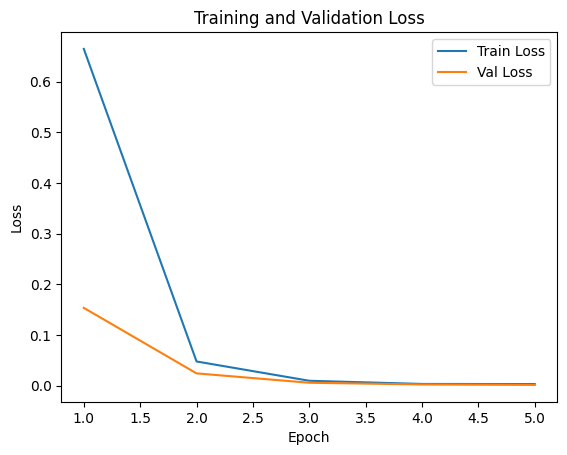

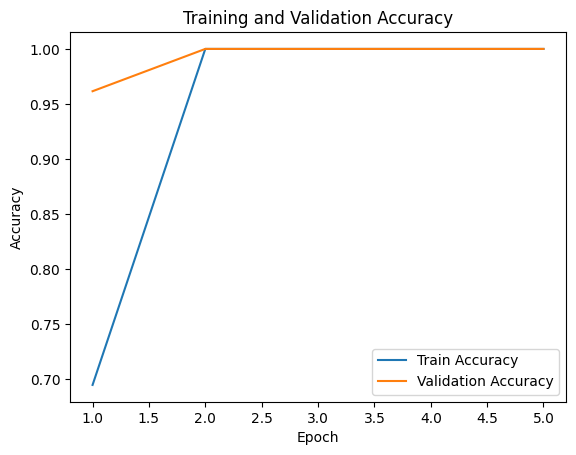

In [24]:
import matplotlib.pyplot as plt

#setting so we haave the spoch in range of 1-5 insted of index 0-4 (better reading)
epochs = range(1, num_epochs + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

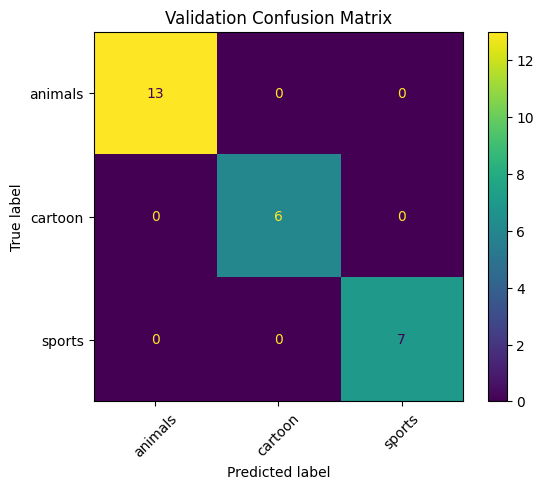

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in val:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.title("Validation Confusion Matrix")
plt.show()

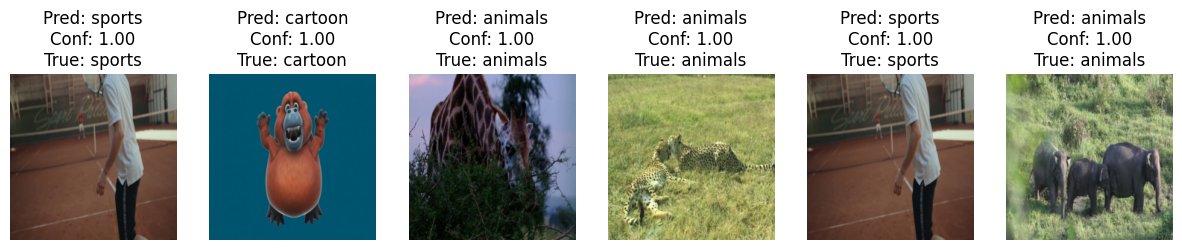

In [26]:
from PIL import Image
import numpy as np

def show_predictions(model, dataset, class_names, num_samples=6):
    model.eval()
    indices = torch.randint(0, len(dataset), (num_samples,))

    images = []
    titles = []

    with torch.no_grad():
        for idx in indices:
            img, label = dataset[idx]  # img is already transformed tensor
            img_batch = img.unsqueeze(0).to(device)

            outputs = model(img_batch)
            probs = torch.softmax(outputs, dim=1)
            conf, pred = torch.max(probs, dim=1)

            # Convert back to [H, W, C] and unnormalize for display
            img_np = img.permute(1, 2, 0).cpu().numpy()
            # Undo normalization approximately (for nicer display)
            img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img_np = np.clip(img_np, 0, 1)

            true_class = class_names[label]
            pred_class = class_names[pred.item()]
            confidence = float(conf)

            titles.append(f"Pred: {pred_class}\nConf: {confidence:.2f}\nTrue: {true_class}")
            images.append(img_np)

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 4))
    for ax, img_np, title in zip(axes, images, titles):
        ax.imshow(img_np)
        ax.set_title(title)
        ax.axis('off')
    plt.show()

show_predictions(model, val_dataset, class_names, num_samples=6)

During this trainging, we see that the model acieved very high accuracy (100%) on both the training and validation sets. Since our dataset contains a limited number of videos per calss (5-6), each frame extraction produced around 40-60 frames per class, manu of which are visually very similar because they come from the same videos and the data split was performed at the frame level ( frames from the same video can appear in both training and validation sets ), we was able to get such perfect scores. But it is in fact some form of data leakage, where our model sees nearly identical frames both during training and evaluation, the 100.% accuracy doesn't really reflect true generalization. In the next step I will move toward real video-level classification (building from this model) where the model predicts the genre of an entire video by aggregating frame-level predictions.

In [27]:
#here we will perform the real video-level genre classification by aggregating predictions from multiple individual frames of a video
# here we addresses the data leakage issue bu making a single prediction fro an entire video, rather than individual frames

import glob # glob to fund paths matching a patter, list all .jpg frames in a directory
from PIL import Image #PIl is the library for image processing we chose and Image is used here to open, load and manupulate individual images files (frames) before passing through the model
import torch #torch used as earlier to create a manipulate tensors, running the models forward pass

# taking frames_dir (path to folder containing video frames, the trained model on the device (cpu), the transform used during training and class_names as the input)
def predict_video_from_frames(frames_dir, model, device, transform, class_names):
    model.eval()
    probs_list = []# list to store the prob distribution for each individual frame processed


    frame_paths = sorted(glob.glob(os.path.join(frames_dir, "*.jpg"))) #using glob to find all the files ending with .jpg (the frames) in sorting order in the specified frames_dir, os.path.join correctly constructs the path
    if len(frame_paths) == 0:
        print("No frames found in:", frames_dir)
        return None

# a performance optimization done, since during the prediction we don´t need to calculate gradients (since we don't update weights during training here)
    with torch.no_grad(): # telling pyTorch to temp stop track thos computations (gradients)
        for img_path in frame_paths: #processing each frame
            img = Image.open(img_path).convert("RGB") # (pillow) load image converting to RGB (ensure color channels)
            img_t = transform(img).unsqueeze(0).to(device) # crucial since the same transformation (transform used during training), resize ToTensor (normalize) applied here, since the model expect same data it was trained on, unsqueeze(0) adding the batch dimension since NN process data in batches, even if it is only one batch

            outputs = model(img_t) #transformed frame fed into the trained model, this is the forward pass for single frame
            probs = torch.softmax(outputs, dim=1)  #raw scores converted here into probabilities (using softmax), a distribution is given between 0-1 (sum up to 1), indicating models confidence for each genre for that single frame loaded
            probs_list.append(probs.cpu()) #collecting frame level probabilities

#here the aggregation happens
    all_probs = torch.cat(probs_list, dim=0) #after processing all frames, the probs from each frame are combined (torch.cat),
    avg_probs = all_probs.mean(dim=0) # mean(dim=0) calculates the average prob for each genre across all frames in that video. making effectiv way to get single, robust videolevel prediction

#the genre with the highest average prob across all grames is choosedn as the cideos predicted genre, along with its confidence, the models overall vote for the entire video
    conf, idx = torch.max(avg_probs, dim=0)
    predicted_class = class_names[idx.item()]
    confidence = conf.item()

#returning the predicted genre, the confidence and tha average probability
    return predicted_class, confidence, avg_probs


In [28]:
!ls /content/data/frames/sports
!ls /content/data/frames/animals
!ls /content/data/frames/cartoon


Sports1  Sports2  Sports3  Sports4  Sports5  Sports6
Animal1  Animal2  Animal3  Animal4  Animal5  Animal6
Cartoon1  Cartoon2  Cartoon3  Cartoon4	Cartoon5  Cartoon6


In [29]:
video_frames_dir = "/content/data/frames/animals/Animal4"
pred_class, confidence, avg_probs = predict_video_from_frames(
    video_frames_dir, model, device, transform, class_names
)
print("Predicted video class:", pred_class)
print("Confidence:", confidence)
print("Class probabilities:")
for cls, p in zip(class_names, avg_probs):
    print(f"  {cls}: {float(p):.4f}")

Predicted video class: animals
Confidence: 0.9981372952461243
Class probabilities:
  animals: 0.9981
  cartoon: 0.0013
  sports: 0.0005


Time to now upload a video file a Gradio, run the function predict_video_from_frames on those frames, and see if we can return a prediction. Instead of uploading a video that the model have seen (trained on) before, I will upload a new video in all of the specified genres, testing the real performance of this model.


In [30]:
!pip install gradio --quiet

import gradio as gr
import tempfile
import shutil
import subprocess

In [31]:
def classify_video(video_path):
  if video_path is None:
    return "No video provided"

  #creating temporary directory to store the frames
  tmp_dir = tempfile.mkdtemp() # Use mkdtemp to create a unique temporary directory
  frames_dir = os.path.join(tmp_dir, "frames")
  os.makedirs(frames_dir, exist_ok = True)

  cmd = [
      "ffmpeg",
      "-i", video_path,
      "-vf", "fps=1", # Extract 1 frame per second
      os.path.join(frames_dir, "frame_%04d.jpg"),
      "-hide_banner",
      "-loglevel", "error"
  ]

  try:
    subprocess.run(cmd, check=True)
    result = predict_video_from_frames(frames_dir, model, device, transform, class_names)

    if result is None:
      return "No frames extracted from video."

    pred_class, confidence, avg_probs = result

    probs_str = "\n".join(
      f"  {cls}: {float(p):.3f}" for cls, p in zip(class_names, avg_probs)
    )

    return f"Predicted class: {pred_class}\nConfidence: {confidence:.3f}\nClass probabilities:\n{probs_str}"

  except subprocess.CalledProcessError:
    return "Error: could not process video with ffmpeg."
  finally:
    # Ensure the temporary directory is always removed
    shutil.rmtree(tmp_dir)

In [32]:
demo = gr.Interface(
    fn=classify_video,
    inputs=gr.Video(label="Upload a short video (sports, animals, or cartoon)"),
    outputs=gr.Textbox(label="Prediction"),
    title="Video Genre Classifier",
    description="Upload a short video clip. The model extracts frames and predicts whether it is sports, animals, or cartoon."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8e4d8a33619b36564c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
